Dataset Raw 

Import thư viện

In [32]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.figsize'] = (20, 10)

1. Đọc dữ liệu và thống kê dữ liệu ban đầu

Đọc dữ liệu từ file CSV 

In [ ]:
df1 = pd.read_csv('retail_sales_dataset.csv')

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


Kiểm tra dòng trùng lặp

In [34]:
# Kiểm tra số lượng bản ghi trùng lặp
df1.duplicated().sum()

np.int64(0)

Kiểm tra kích thước dữ liệu

In [35]:
df1.shape

(120000, 17)

Kiểm tra danh sách cột

In [36]:
# Kiểm tra các cột trong DataFrame
df1.columns

Index(['transaction_id', 'transaction_date', 'customer_id', 'customer_gender',
       'customer_age_group', 'customer_segment', 'product_id', 'product_name',
       'category', 'brand', 'quantity', 'unit_price', 'discount_pct',
       'sales_amount', 'payment_method', 'sales_channel', 'region'],
      dtype='str')

Kiểm tra kiểu dữ liệu

In [37]:
# Kiểm tra kiểu dữ liệu của các cột
df1.dtypes

transaction_id            str
transaction_date          str
customer_id               str
customer_gender           str
customer_age_group        str
customer_segment          str
product_id                str
product_name              str
category                  str
brand                     str
quantity                int64
unit_price            float64
discount_pct            int64
sales_amount          float64
payment_method            str
sales_channel             str
region                    str
dtype: object

2. Khám phá dữ liệu và tiền xử lý cơ bản

Thống kê mô tả các cột số

In [38]:
# Kiểm tra thống kê mô tả của các cột số liệu
df1.describe()

,quantity,unit_price,discount_pct,sales_amount
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,1.662908,240.621785,5.496500,377.975454
std,1.014291,146.457057,8.193257,356.893357
min,1.000000,7.730000,0.000000,5.410000
25%,1.000000,102.010000,0.000000,136.860000
50%,1.000000,238.750000,0.000000,295.980000
75%,2.000000,379.000000,10.000000,461.500000
max,5.000000,493.510000,30.000000,2467.550000


Loại bỏ cột định danh không cần thiết

In [39]:
# Loại bỏ các cột có giá trị duy nhất cao và không cần thiết cho mô hình
df2 = df1.drop(['transaction_id', 'customer_id', 'product_id','quantity'], axis=1)
df2.shape

(120000, 13)

Kiểm tra missing value

In [40]:
# Kiểm tra các giá trị thiếu trong DataFrame sau khi loại bỏ các cột không cần thiết
df2.isnull().sum()

transaction_date      0
customer_gender       0
customer_age_group    0
customer_segment      0
product_name          0
category              0
brand                 0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

3. Kiểm tra và xử lý outlier

Boxplot cho sales_amount

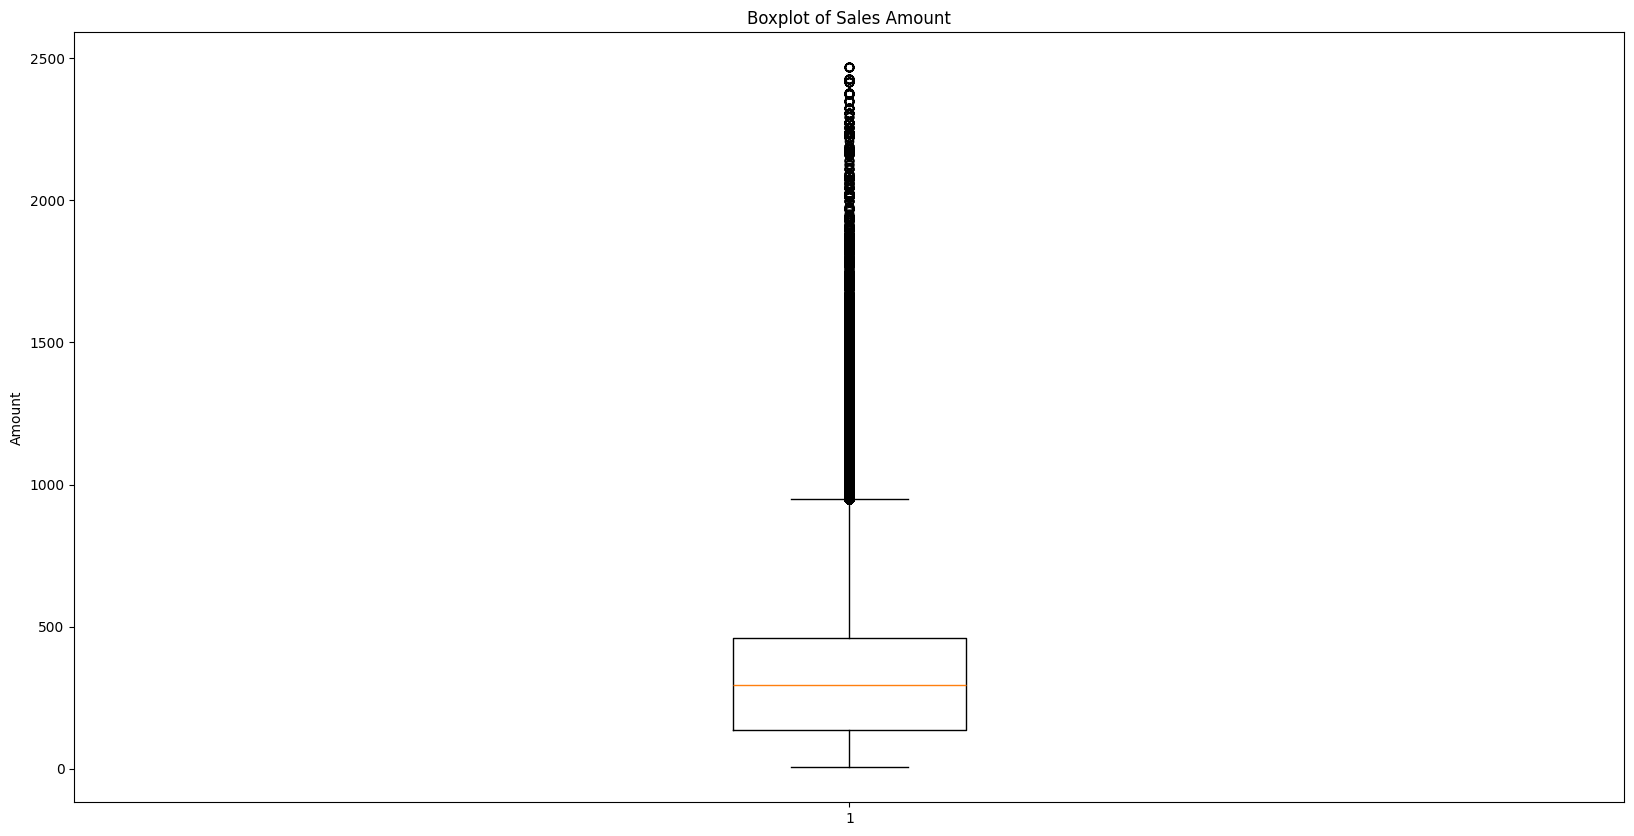

In [41]:
# Vẽ biểu đồ boxplot để kiểm tra phân phối của cột 'sales_amount'
plt.boxplot(df2['sales_amount'])
plt.title("Boxplot of Sales Amount")
plt.ylabel("Amount")
plt.show()

Lọc outlier của sales_amount bằng IQR

In [42]:
# Dùng phương pháp IQR để xác định ngưỡng cho outliers
Q1 = df2['sales_amount'].quantile(0.25)
Q3 = df2['sales_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df2[(df2.sales_amount < lower_limit) | (df2.sales_amount > upper_limit)]

,transaction_date,customer_gender,customer_age_group,customer_segment,product_name,category,brand,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
10,2024-02-27,Male,35-44,VIP,Novel,Books,Brand 3,379.00,0,1516.00,Cash,Online,South
21,2025-06-24,Female,25-34,Returning,Bread,Groceries,Brand 1,474.70,0,949.40,Cash,In-Store,East
29,2025-04-18,Male,45-54,New,Bread,Groceries,Brand 3,405.16,0,1620.64,Credit Card,Mobile App,Central
36,2025-08-31,Other,18-24,VIP,Towel,Home,Brand 3,354.89,5,1011.44,Gift Card,Mobile App,Central
46,2024-02-06,Other,55+,Returning,Storage Box,Home,Brand 1,493.51,0,987.02,PayPal,Online,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...
119967,2025-01-15,Male,25-34,New,Smartwatch,Electronics,Brand 1,355.50,0,1422.00,Credit Card,Online,South
119978,2025-11-29,Female,18-24,Loyal,Smartphone,Electronics,Brand 3,367.34,0,1469.36,Credit Card,Online,East
119981,2024-02-29,Female,25-34,Loyal,Towel,Home,Brand 2,408.65,5,1552.87,Credit Card,Online,North
119983,2025-06-04,Other,55+,Returning,Yoga Mat,Sports,Brand 2,386.78,0,1160.34,PayPal,Mobile App,West


4. Xử lý biến mục tiêu

Log transform target sales_amount

In [43]:
# Dùng phương pháp Log transformation cho sales_amount
df2['sales_amount_log'] = np.log1p(df2['sales_amount'])

Histogram trước khi log transform

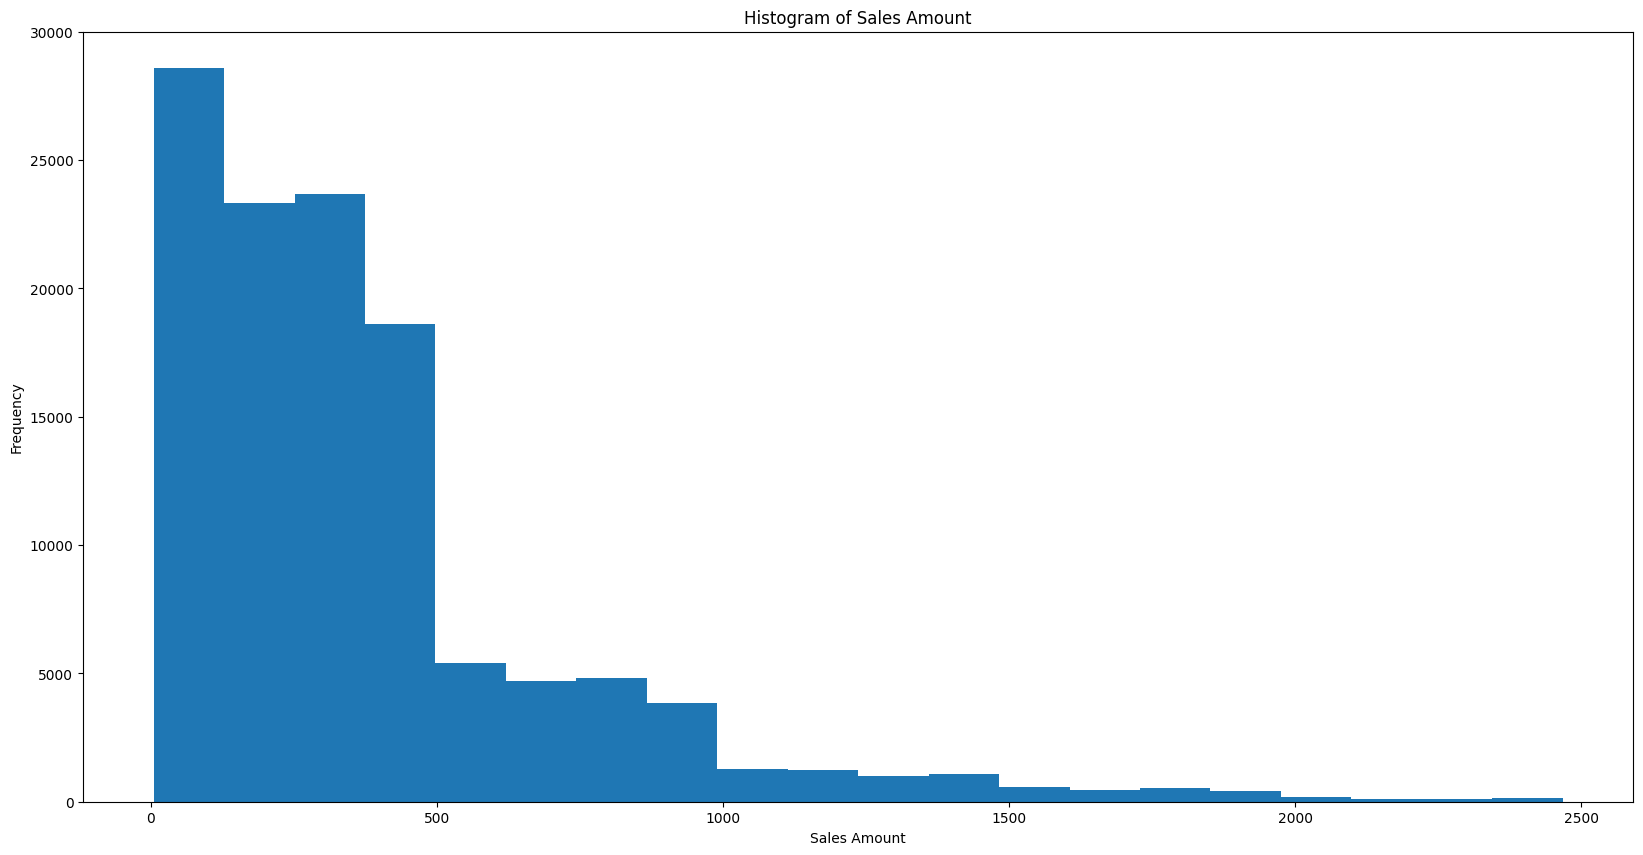

In [44]:
# Vẽ histogram của sales_amount trước khi log transform
plt.hist(df2['sales_amount'], bins=20)
plt.title("Histogram of Sales Amount")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.show()

Histogram của sales_amount_log

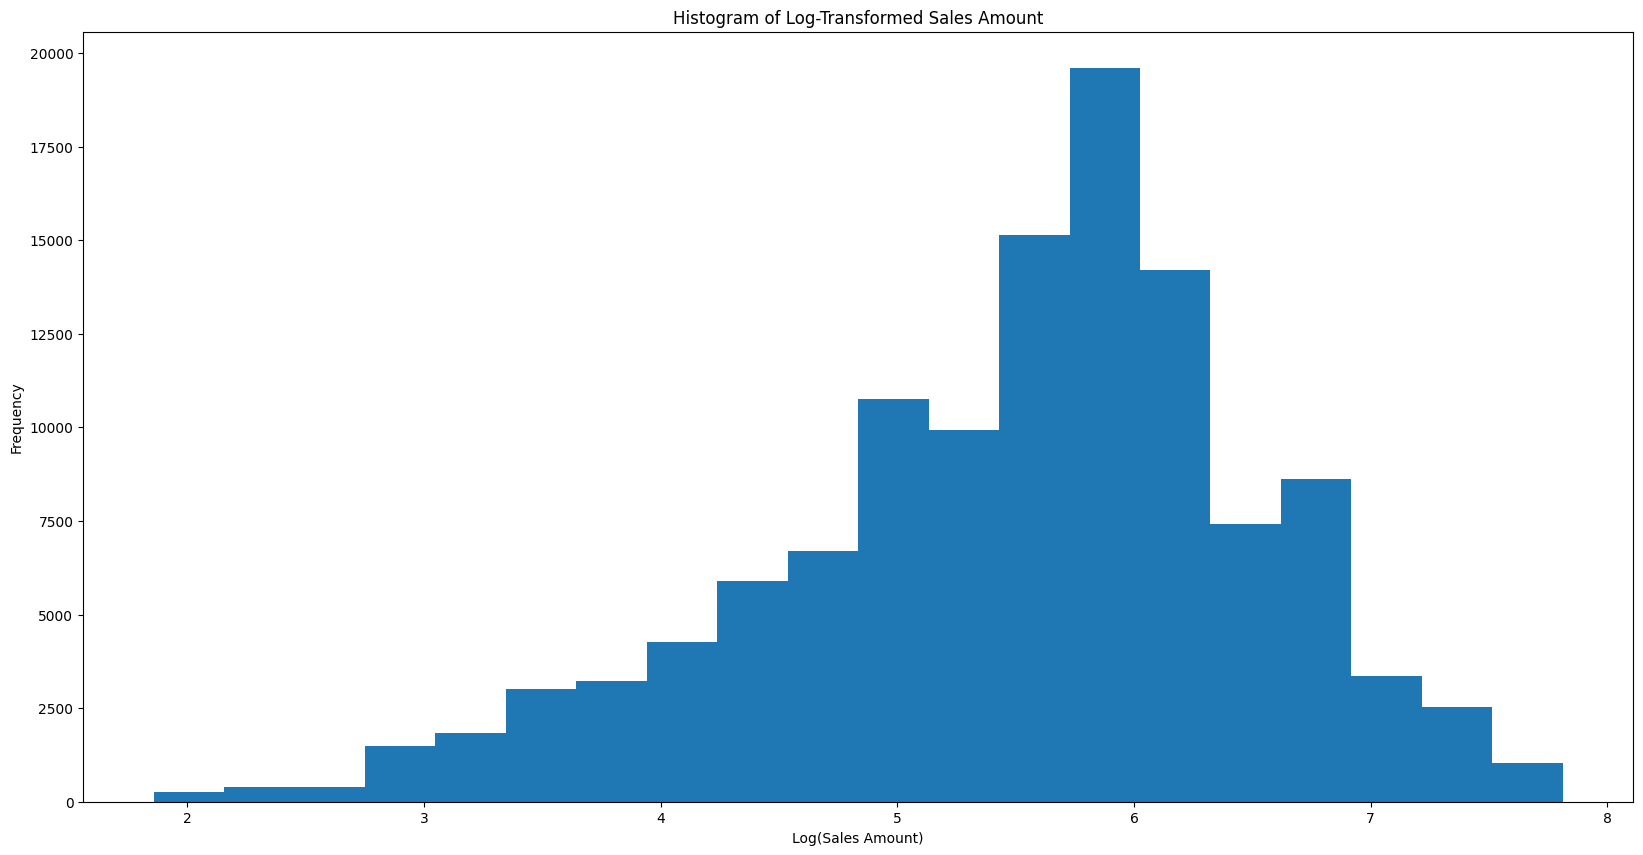

In [45]:
# Vẽ biểu đồ histogram để kiểm tra phân phối của cột 'sales_amount_log'
plt.hist(df2['sales_amount_log'], bins=20)
plt.title("Histogram of Log-Transformed Sales Amount")
plt.xlabel("Log(Sales Amount)")
plt.ylabel("Frequency")
plt.show()

Bỏ cột gốc sales_amount

In [46]:
df3 = df2.drop(['sales_amount'], axis=1)

5. Mã hóa dữ liệu phân loại 

 Tạo bản copy trước khi mã hóa

In [47]:
# Mã hóa dữ liệu
df4 = df3.copy()

Ordinal encoding cho customer_age_group

In [48]:
# Ordinary Encoding - customer_age_group
age_mapping = {
    '18-24': 0,
    '25-34': 1,
    '35-44': 2,
    '45-54': 3,
    '55+': 4
}
df4['customer_age_group_encoded'] = df4['customer_age_group'].map(age_mapping)

Kiểm tra kết quả mapping nhóm tuổi

In [49]:
print(df4['customer_age_group_encoded'].value_counts())
print("Số lượng dòng bị lỗi map:", df4['customer_age_group_encoded'].isna().sum())

customer_age_group_encoded
2    24196
4    24078
0    23941
3    23919
1    23866
Name: count, dtype: int64
Số lượng dòng bị lỗi map: 0


Xóa cột tuổi dạng chữ

In [50]:
df5 = df4.drop(['customer_age_group'], axis=1)
df5.head()

,transaction_date,customer_gender,customer_segment,product_name,category,brand,unit_price,discount_pct,payment_method,sales_channel,region,sales_amount_log,customer_age_group_encoded
0,2024-04-24,Other,Returning,Dumbbells,Sports,Brand 1,313.53,20,Debit Card,Online,North,6.219894,2
1,2025-07-12,Other,New,Running Shoes,Sports,Brand 3,366.16,0,Credit Card,Online,South,5.905798,3
2,2025-06-01,Male,Returning,Sneakers,Clothing,Brand 3,27.99,0,Gift Card,In-Store,South,3.366951,4
3,2025-08-26,Male,VIP,Sunscreen,Beauty,Brand 1,102.01,15,Cash,In-Store,South,5.161466,1
4,2024-12-10,Male,New,Sneakers,Clothing,Brand 1,259.55,0,Cash,In-Store,Central,5.562795,3


 One-hot encoding cho các cột phân loại còn lại

In [51]:
df6 = df5.copy()

ohe_columns = [
    'customer_gender',
    'customer_segment',
    'product_name',
    'category',
    'brand',
    'payment_method',
    'sales_channel',
    'region'
]

df7_encoded = pd.get_dummies(
    df6,
    columns=ohe_columns,
    dtype=int
)
# One-Hot Encoding cho các cột phân loại còn lại
ohe_columns = [
    'customer_gender', 'customer_segment', 'product_name', 
    'category', 'brand', 'payment_method', 'sales_channel', 'region'
]
df7_encoded = pd.get_dummies(df6, columns=ohe_columns, dtype=int)
df7_encoded.head()

,transaction_date,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,customer_gender_Female,customer_gender_Male,customer_gender_Other,customer_segment_Loyal,customer_segment_New,...,payment_method_Gift Card,payment_method_PayPal,sales_channel_In-Store,sales_channel_Mobile App,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West
0,2024-04-24,313.53,20,6.219894,2,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
1,2025-07-12,366.16,0,5.905798,3,0,0,1,0,1,...,0,0,0,0,1,0,0,0,1,0
2,2025-06-01,27.99,0,3.366951,4,0,1,0,0,0,...,1,0,1,0,0,0,0,0,1,0
3,2025-08-26,102.01,15,5.161466,1,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0
4,2024-12-10,259.55,0,5.562795,3,0,1,0,0,1,...,0,0,1,0,0,1,0,0,0,0


Kiểm tra kích thước sau one-hot encoding

In [52]:
df7_encoded.shape

(120000, 76)

Xem danh sách cột sau encoding

In [53]:
df7_encoded.columns

Index(['transaction_date', 'unit_price', 'discount_pct', 'sales_amount_log',
       'customer_age_group_encoded', 'customer_gender_Female',
       'customer_gender_Male', 'customer_gender_Other',
       'customer_segment_Loyal', 'customer_segment_New',
       'customer_segment_Returning', 'customer_segment_VIP',
       'product_name_Bedsheet', 'product_name_Bluetooth Speaker',
       'product_name_Board Game', 'product_name_Bread',
       'product_name_Building Blocks', 'product_name_Cereal',
       'product_name_Children Book', 'product_name_Coffee',
       'product_name_Cookbook', 'product_name_Cookware Set',
       'product_name_Doll', 'product_name_Dress', 'product_name_Dumbbells',
       'product_name_Football', 'product_name_Headphones',
       'product_name_Jacket', 'product_name_Jeans', 'product_name_Lamp',
       'product_name_Laptop', 'product_name_Lipstick', 'product_name_Milk',
       'product_name_Moisturizer', 'product_name_Notebook',
       'product_name_Novel', 'product

6. Feature engineering

Tạo cột năm, tháng, ngày, thứ trong tuần

In [54]:
# Chuyển sang datetime

df7_encoded['transaction_date'] = pd.to_datetime(
    df7_encoded['transaction_date']
)

# Tạo feature thời gian

df7_encoded['transaction_year'] = df7_encoded['transaction_date'].dt.year
df7_encoded['transaction_month'] = df7_encoded['transaction_date'].dt.month
df7_encoded['transaction_day'] = df7_encoded['transaction_date'].dt.day
df7_encoded['transaction_dayofweek'] = df7_encoded['transaction_date'].dt.dayofweek

Xem dữ liệu sau khi thêm đặc trưng thời gian

In [55]:
df7_encoded.head()

,transaction_date,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,customer_gender_Female,customer_gender_Male,customer_gender_Other,customer_segment_Loyal,customer_segment_New,...,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West,transaction_year,transaction_month,transaction_day,transaction_dayofweek
0,2024-04-24,313.53,20,6.219894,2,0,0,1,0,0,...,1,0,0,1,0,0,2024,4,24,2
1,2025-07-12,366.16,0,5.905798,3,0,0,1,0,1,...,1,0,0,0,1,0,2025,7,12,5
2,2025-06-01,27.99,0,3.366951,4,0,1,0,0,0,...,0,0,0,0,1,0,2025,6,1,6
3,2025-08-26,102.01,15,5.161466,1,0,1,0,0,0,...,0,0,0,0,1,0,2025,8,26,1
4,2024-12-10,259.55,0,5.562795,3,0,1,0,0,1,...,0,1,0,0,0,0,2024,12,10,1


7. Chuẩn hóa, chia train/test và xuất dữ liệu

Chia tập train test theo trục thời gian 

In [56]:
#CHIA TRAIN/TEST THEO THỜI GIAN TRƯỚC
df_chronological = df7_encoded.sort_values(
    'transaction_date'
)

split_point = int(len(df_chronological) * 0.8)

train_data = df_chronological.iloc[:split_point].copy()
test_data = df_chronological.iloc[split_point:].copy()


Chuẩn hóa thang đo bằng StandardScaler
Chuẩn hóa giúp đưa các cột số về cùng thang đo. Sau chuẩn hóa, giá trị thường có trung bình gần 0 và độ lệch chuẩn gần 1.

 Chuẩn hóa một số cột số
Dùng `StandardScaler` để chuẩn hóa các cột:
- `unit_price`
- `sales_amount_log`
Sau chuẩn hóa, mỗi cột được đưa về dạng z-score:
`z = (x - mean) / std`
Chuẩn hóa giúp mô hình nhạy với khoảng cách hoặc gradient học ổn định hơn.

In [57]:
# Chuẩn hóa các cột số liệu để đưa về cùng thang đo
from sklearn.preprocessing import StandardScaler
numeric_cols = [
    'unit_price',
    'sales_amount_log',
]

scaler = StandardScaler()

# Fit chỉ trên train
train_data[numeric_cols] = scaler.fit_transform(
    train_data[numeric_cols]
)

# Test chỉ transform
test_data[numeric_cols] = scaler.transform(
    test_data[numeric_cols]
)
df7_encoded.head()

,transaction_date,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,customer_gender_Female,customer_gender_Male,customer_gender_Other,customer_segment_Loyal,customer_segment_New,...,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West,transaction_year,transaction_month,transaction_day,transaction_dayofweek
0,2024-04-24,313.53,20,6.219894,2,0,0,1,0,0,...,1,0,0,1,0,0,2024,4,24,2
1,2025-07-12,366.16,0,5.905798,3,0,0,1,0,1,...,1,0,0,0,1,0,2025,7,12,5
2,2025-06-01,27.99,0,3.366951,4,0,1,0,0,0,...,0,0,0,0,1,0,2025,6,1,6
3,2025-08-26,102.01,15,5.161466,1,0,1,0,0,0,...,0,0,0,0,1,0,2025,8,26,1
4,2024-12-10,259.55,0,5.562795,3,0,1,0,0,1,...,0,1,0,0,0,0,2024,12,10,1


Kiểm tra thống kê sau chuẩn hóa

In [58]:
print(train_data[numeric_cols].describe().round(2))

       unit_price  sales_amount_log
count    96000.00          96000.00
mean        -0.00             -0.00
std          1.00              1.00
min         -1.59             -3.54
25%         -0.94             -0.56
50%         -0.02              0.19
75%          0.94              0.62
max          1.72              2.25


In [59]:
print(test_data[numeric_cols].describe().round(2))

       unit_price  sales_amount_log
count    24000.00          24000.00
mean        -0.01             -0.01
std          1.00              1.00
min         -1.59             -3.54
25%         -0.95             -0.57
50%         -0.02              0.19
75%          0.94              0.60
max          1.72              2.25


Lưu file 

In [60]:
train_data.to_csv(
    'retail_train_80.csv',
    index=False
)

test_data.to_csv(
    'retail_test_20.csv',
    index=False
)

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (96000, 80)
Test shape: (24000, 80)


Xem dữ liệu cuối cùng sau khi xử lý

In [61]:
df_chronological.head()

,transaction_date,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,customer_gender_Female,customer_gender_Male,customer_gender_Other,customer_segment_Loyal,customer_segment_New,...,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West,transaction_year,transaction_month,transaction_day,transaction_dayofweek
74296,2024-01-01,190.40,20,5.032527,4,0,1,0,1,0,...,0,0,0,1,0,0,2024,1,1,0
60224,2024-01-01,320.59,0,5.773277,3,0,0,1,0,0,...,1,0,1,0,0,0,2024,1,1,0
74010,2024-01-01,53.35,0,3.995445,3,0,0,1,0,0,...,0,0,1,0,0,0,2024,1,1,0
85604,2024-01-01,53.35,0,3.995445,1,0,0,1,0,0,...,0,0,0,1,0,0,2024,1,1,0
98131,2024-01-01,387.26,0,5.961675,0,1,0,0,0,0,...,0,1,0,0,0,0,2024,1,1,0


Feature selection bằng correlation heatmap

Phần cuối vẽ ma trận tương quan để xem các biến có quan hệ tuyến tính mạnh hay yếu với nhau, đặc biệt là với biến mục tiêu `sales_amount_log`.


Vẽ correlation heatmap

<Axes: >

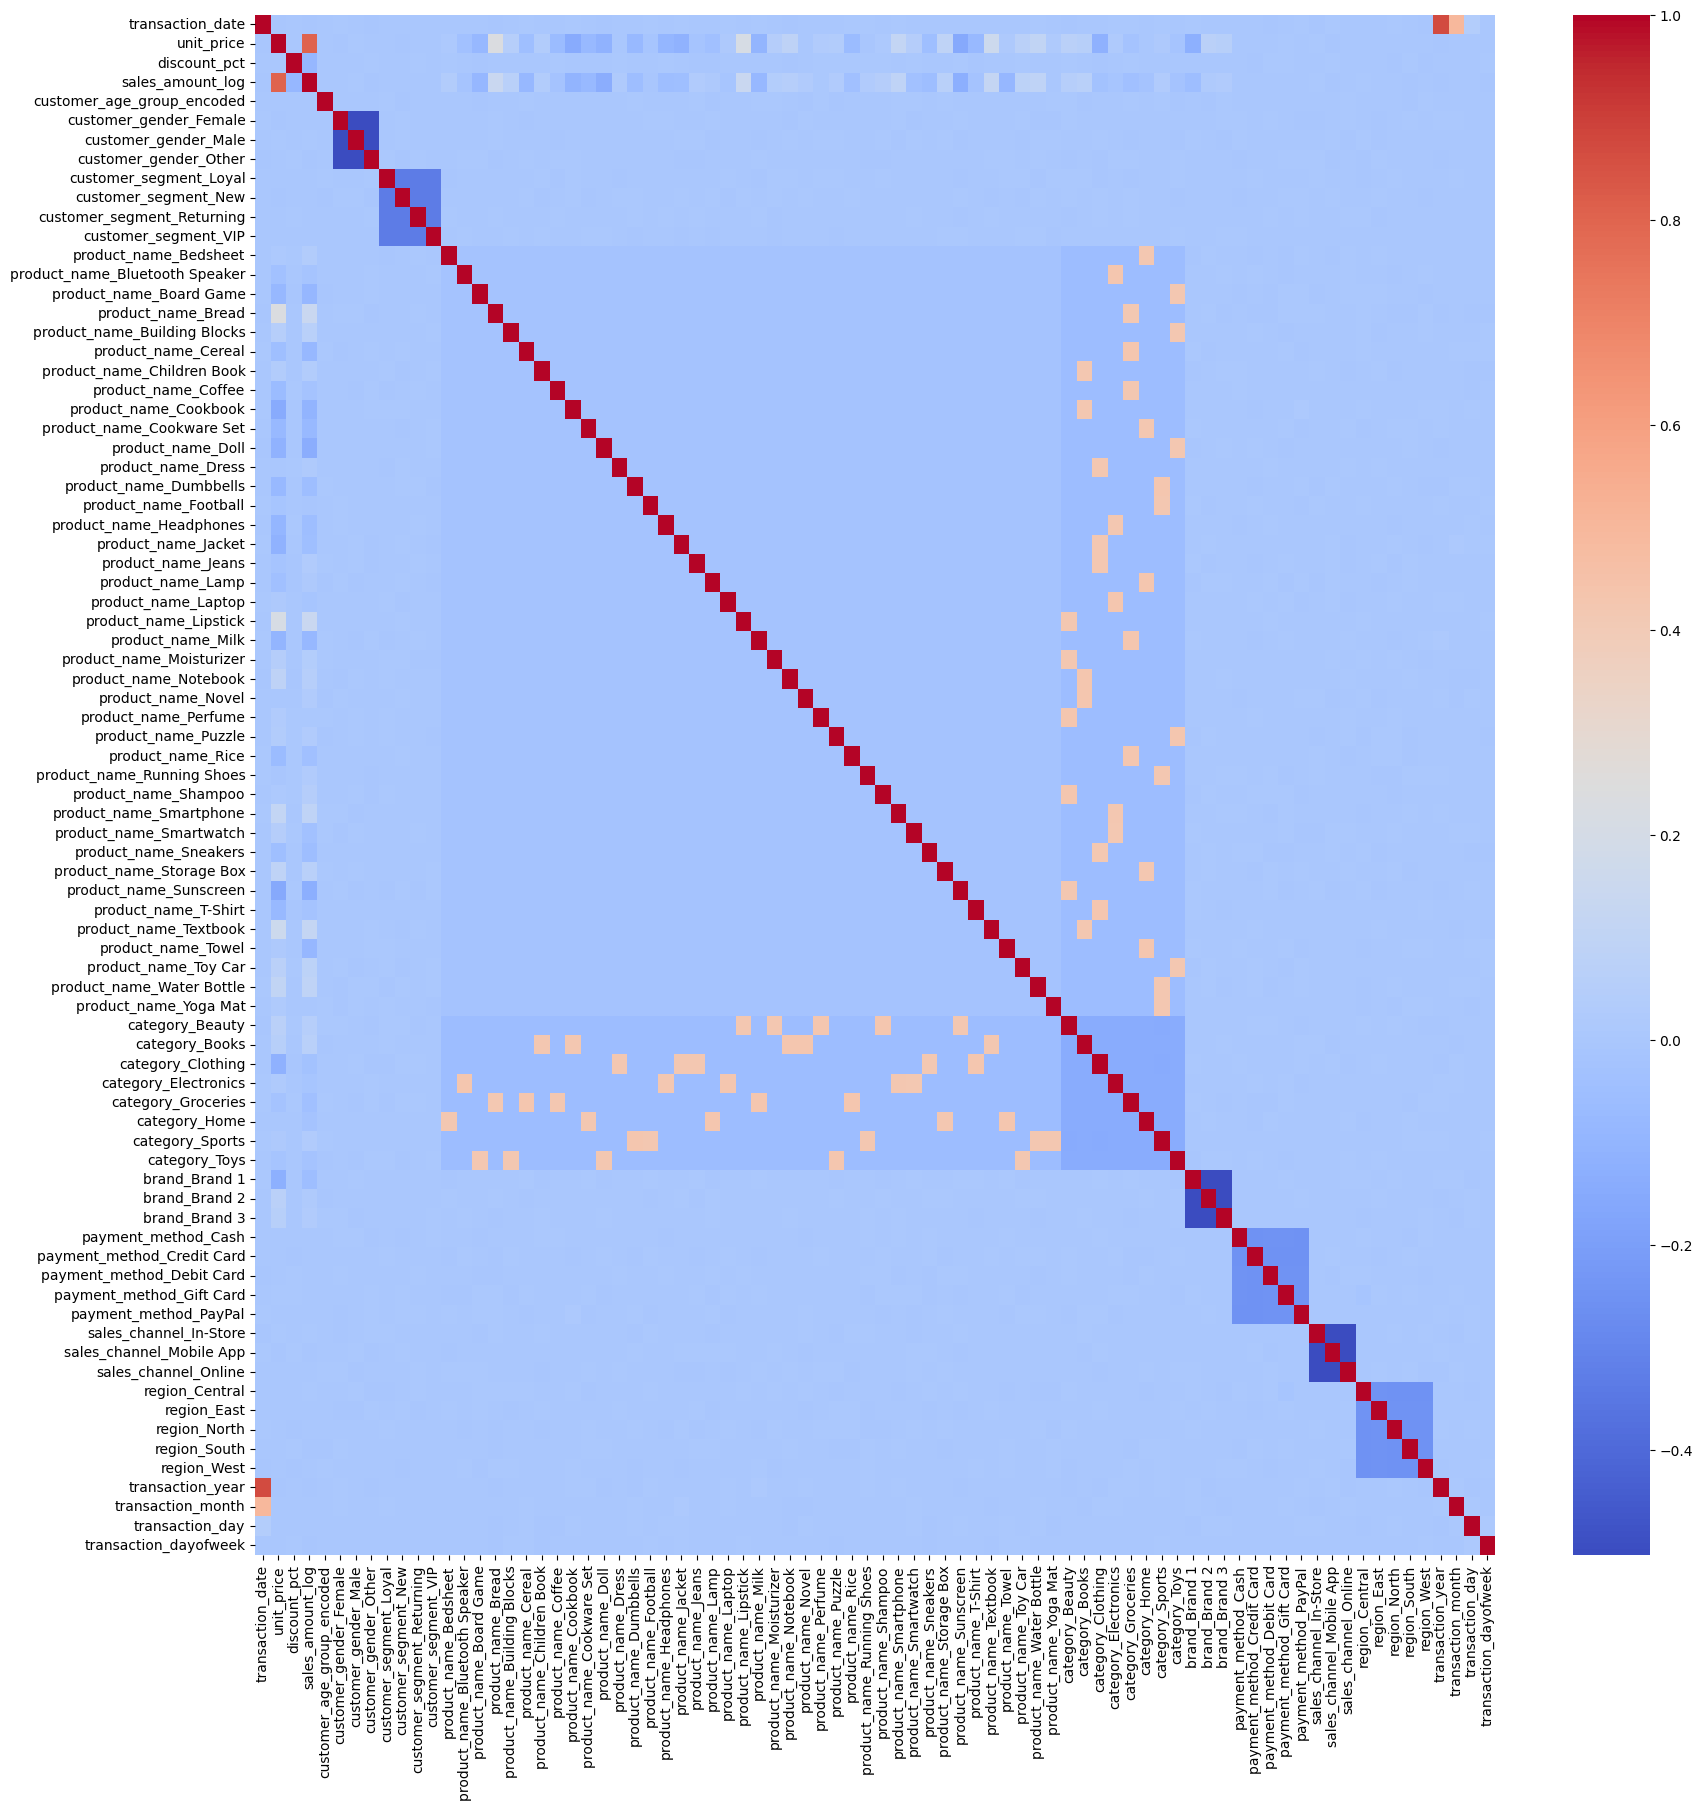

In [62]:
# Correlation Matrix with Heatmap
import seaborn as sns
X = df_chronological.iloc[:, df_chronological.columns != 'sales_amount_log']
Y = df_chronological['sales_amount_log']
corrmat = df_chronological.corr()
top_corr_feature = corrmat.index
plt.figure(figsize=(20, 20))
sns.heatmap(corrmat, annot=False, cmap='coolwarm')

### Giải thích biểu đồ heatmap

Heatmap này khá lớn vì dữ liệu sau one-hot encoding có nhiều cột. Khi nhìn heatmap:

- Đường chéo chính thường có tương quan = 1 vì mỗi biến tương quan hoàn hảo với chính nó.
- Những ô có màu nổi bật hơn là các cặp biến có tương quan mạnh hơn.
- Nếu một feature tương quan mạnh với `sales_amount_log`, feature đó có thể hữu ích cho mô hình tuyến tính.
- Nếu hai feature tương quan quá mạnh với nhau, có thể có trùng lặp thông tin.

Tuy nhiên, do có quá nhiều cột one-hot, heatmap toàn bộ hơi khó đọc khi trình bày. Nếu báo cáo, nên rút gọn bằng cách chỉ lấy top 10–20 feature có tương quan cao nhất với target.
